# M2 — Feature Engineering

Goal: turn each variable-length point-cloud tile into a fixed-length feature vector for the
M2 baseline (per `ROADMAP.md` M2), and sanity-check that the engineered features actually
separate the six classes before spending time training classifiers.

All aggregation logic lives in `src/features.py` — this notebook only builds the feature
table, inspects it, and visualizes it (same split of responsibility as `01_eda.ipynb`).

**Design recap** (see `src/features.py` docstring for the full reasoning):
- Aggregate stats (mean, std, 5/25/50/75/95th percentiles) over 16 raw columns: geometry
  descriptors, colour, intensity, return count, the mean-intensity grids, edge area, and the
  intensity-gradient column.
- `global_x/y/z` are **excluded** — they encode map position, not tile appearance, and would
  let a classifier cheat by memorizing where tiles are instead of learning lane geometry.
- Four explicit engineered features: `n_points`, `x_range`, `y_range`, `point_density`. `x_range`
  in particular encodes road width, which should correlate directly with lane count.
- `mean_intensity_0.3m_x/y` and `edge_area` were seen in `01_eda.ipynb` §2 to have a mean of
  ~0 in every class — i.e. already centered/differenced signals — so we expect their `std`/
  percentile stats to carry the signal, not their `mean`.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import CLASSES, get_splits
from src.features import engineered_feature_names, build_feature_matrix

## 1. Build the feature table (train split only)

We only build/inspect features on the frozen **train** split here — the same discipline that
keeps `splits.json`'s test set frozen (see `01_eda.ipynb` §4). Any feature-engineering
decision made by eyeballing val/test statistics would leak information from the sets we
later evaluate on.

In [2]:
splits = get_splits()
train_samples = splits["train"]

X_train, y_train, train_paths = build_feature_matrix(train_samples)
feature_names = engineered_feature_names()

df = pd.DataFrame(X_train, columns=feature_names)
df["class"] = pd.Categorical([CLASSES[label] for label in y_train], categories=CLASSES, ordered=True)

print(f"{X_train.shape[0]} samples x {X_train.shape[1]} features")
df.head()

1140 samples x 123 features


,local_x_mean,local_x_std,local_x_p5,local_x_p25,local_x_p50,local_x_p75,local_x_p95,local_z_mean,local_z_std,local_z_p5,local_z_p25,local_z_p50,local_z_p75,local_z_p95,red_mean,red_std,red_p5,red_p25,red_p50,red_p75,red_p95,green_mean,green_std,green_p5,green_p25,green_p50,green_p75,green_p95,blue_mean,blue_std,blue_p5,blue_p25,blue_p50,blue_p75,blue_p95,intensity_mean,intensity_std,intensity_p5,intensity_p25,intensity_p50,...,mean_intensity_1.5m_y_mean,mean_intensity_1.5m_y_std,mean_intensity_1.5m_y_p5,mean_intensity_1.5m_y_p25,mean_intensity_1.5m_y_p50,mean_intensity_1.5m_y_p75,mean_intensity_1.5m_y_p95,mean_intensity_0.3m_x_mean,mean_intensity_0.3m_x_std,mean_intensity_0.3m_x_p5,mean_intensity_0.3m_x_p25,mean_intensity_0.3m_x_p50,mean_intensity_0.3m_x_p75,mean_intensity_0.3m_x_p95,mean_intensity_1.5m_x_mean,mean_intensity_1.5m_x_std,mean_intensity_1.5m_x_p5,mean_intensity_1.5m_x_p25,mean_intensity_1.5m_x_p50,mean_intensity_1.5m_x_p75,mean_intensity_1.5m_x_p95,edge_area_mean,edge_area_std,edge_area_p5,edge_area_p25,edge_area_p50,edge_area_p75,edge_area_p95,intensity_gradient_pos_mean,intensity_gradient_pos_std,intensity_gradient_pos_p5,intensity_gradient_pos_p25,intensity_gradient_pos_p50,intensity_gradient_pos_p75,intensity_gradient_pos_p95,n_points,x_range,y_range,point_density,class
0,14.202842,8.427855,1.302689,7.104676,14.226810,21.211785,28.326875,0.317386,0.135429,0.11,0.22,0.31,0.40,0.56,142.801695,37.035686,61.239216,130.509804,153.600000,168.658824,188.134902,143.786465,33.577099,66.258824,133.521569,153.600000,164.643137,187.733333,132.499149,30.434823,66.258824,124.486275,139.545098,149.584314,176.690196,33601.499892,4507.564576,23963.0,31216.0,34143.0,...,0.000717,0.002826,0.0,0.000000e+00,0.000000,0.000000,0.010417,-6.271930e-17,0.000823,-0.000650,-0.000650,-0.000650,0.000789,0.001533,0.000810,0.000553,0.000000,0.000719,0.000728,0.000728,0.002183,-6.271930e-17,0.017252,-0.000650,-0.000650,-0.000650,-0.000650,-0.000650,-0.000113,0.000247,-0.000650,0.0,0.0,0.0,0.000000,4613.0,29.993822,9.998672,15.381876,split6lanes
1,3.914694,2.320113,0.331139,1.842354,3.924003,5.870894,7.600709,0.173464,0.081489,0.06,0.11,0.17,0.24,0.31,142.346517,16.240109,128.401569,133.521569,138.541176,148.580392,174.682353,142.948870,16.284111,128.501961,134.525490,138.541176,149.584314,177.694118,130.116601,18.464222,100.392157,122.478431,127.498039,137.788235,162.635294,34227.748810,5925.151006,25993.9,29288.5,34274.0,...,0.002517,0.006800,0.0,0.000000e+00,0.000000,0.000000,0.020000,8.392757e-18,0.005465,-0.002381,-0.002381,-0.002381,-0.002381,0.012544,0.004504,0.005576,0.000000,0.000000,0.000000,0.007463,0.014925,8.591012e-18,0.021692,-0.002381,-0.002381,-0.002381,-0.002381,-0.002381,0.000578,0.004336,-0.002381,0.0,0.0,0.0,0.017227,840.0,7.988837,5.360546,19.614926,2lanes
2,6.980602,4.039188,0.676792,3.520946,6.963176,10.460192,13.306476,0.291378,0.093035,0.15,0.22,0.29,0.36,0.44,96.249995,49.852341,37.145098,41.160784,120.470588,132.517647,178.346667,102.802278,42.628700,52.203922,57.223529,120.470588,132.517647,175.686275,101.842485,34.695600,61.239216,67.262745,111.435294,122.478431,162.635294,33410.748430,4821.927994,25121.0,29615.5,34034.0,...,0.014773,0.028414,0.0,6.938894e-18,0.001573,0.017057,0.065418,3.764650e-17,0.046937,-0.056907,-0.038913,-0.016298,0.037829,0.089644,0.024423,0.012328,0.011307,0.014474,0.019890,0.027064,0.051815,4.182944e-17,0.154675,-0.056907,-0.056907,-0.056907,-0.056907,0.371664,0.005342,0.037575,-0.056907,0.0,0.0,0.0,0.120126,2548.0,13.996299,9.997030,18.210221,crossing
3,12.457605,7.182190,1.865746,6.144318,12.262781,18.570125,23.879188,0.679347,0.797457,0.14,0.28,0.41,0.53,2.85,118.207679,55.851982,30.117647,47.184314,139.545098,166.650980,180.705882,122.257816,48.763283,48.188235,60.235294,141.552941,161.631373,178.698039,115.262165,41.295340,55.215686,66.258824,131.513725,145.568627,166.650980,34135.717554,5915.443438,25536.0,29796.0,32800.0,...,0.023744,0.051821,0.0,0.000000e+00,0.000000,0.011905,0.

## 2. Sanity-check: does the width hypothesis hold?

`x_range` was engineered specifically because lane count should correlate with how far points
spread across the road (driving direction is along `local_y`, see `CLAUDE.md`). If the feature
is doing its job, class medians should roughly separate by lane count.

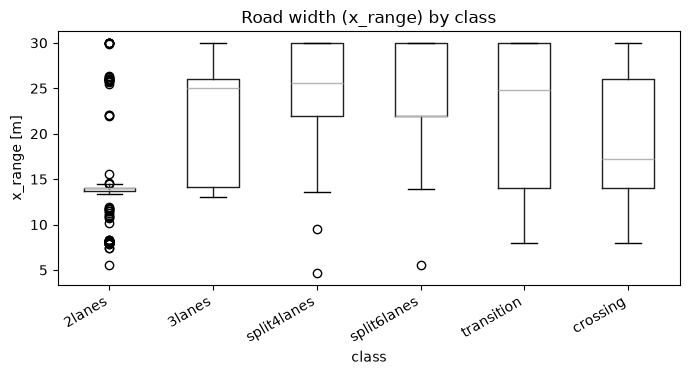

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="x_range", by="class", ax=ax, grid=False)
ax.set_xticklabels(CLASSES, rotation=30, ha="right")
plt.suptitle("")
ax.set_title("Road width (x_range) by class")
ax.set_ylabel("x_range [m]")
plt.tight_layout()
plt.show()

In [4]:
df.groupby("class", observed=True)["x_range"].median()

class
2lanes         13.991071
3lanes         24.996535
split4lanes    25.619436
split6lanes    21.994406
transition     24.786293
crossing       17.189242
Name: x_range, dtype: float64

**Observation:** median `x_range` by class (narrowest to widest): 2lanes < crossing < split6lanes < transition < 3lanes < split4lanes

- `2lanes`: 13.99 m
- `3lanes`: 25.00 m
- `split4lanes`: 25.62 m
- `split6lanes`: 21.99 m
- `transition`: 24.79 m
- `crossing`: 17.19 m

The hypothesis only partly holds. `2lanes` is clearly the narrowest tile, as expected — but
`3lanes`, `split4lanes`, `split6lanes`, and `transition` all cluster within a few metres of each other instead of ranking cleanly by lane count, and `crossing` is the second-*narrowest* class despite being a junction.
A single scalar can't fully capture "how many lanes" — a `split4lanes` tile likely isn't
uniformly 4-lanes-wide for its whole length, and a `crossing` tile's `local_x` extent depends
on where the tile was cut relative to the junction, not the number of roads meeting there.
This is exactly the limitation M3's BEV/CNN approach (ROADMAP M3) is meant to address: it
sees the full 2D spatial layout instead of one collapsed number per axis. For M2, `x_range`
should still help (it clearly isolates `2lanes`), but the classifier will need the other
aggregate columns — intensity and geometry descriptors — to tell the rest apart.

## 3. Point count & density by class

`n_points` and `point_density` are cheap, purely geometric signals — worth checking whether
they already separate classes before relying on the more expensive per-column stats.

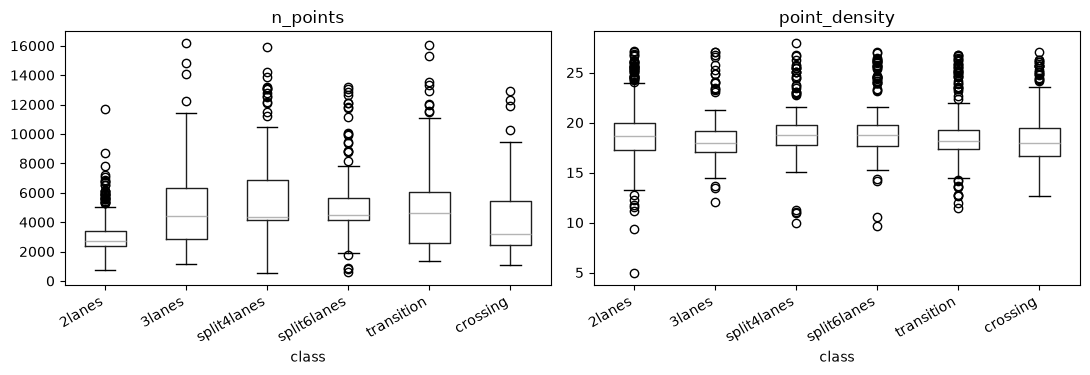

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.boxplot(column="n_points", by="class", ax=axes[0], grid=False)
df.boxplot(column="point_density", by="class", ax=axes[1], grid=False)
for ax, title in zip(axes, ["n_points", "point_density"]):
    ax.set_xticklabels(CLASSES, rotation=30, ha="right")
    ax.set_title(title)
plt.suptitle("")
plt.tight_layout()
plt.show()

## 4. Intensity signal

The project brief flags intensity as "the most important factor apart from the geometry" —
worth a direct look at whether the aggregate intensity stats separate classes.

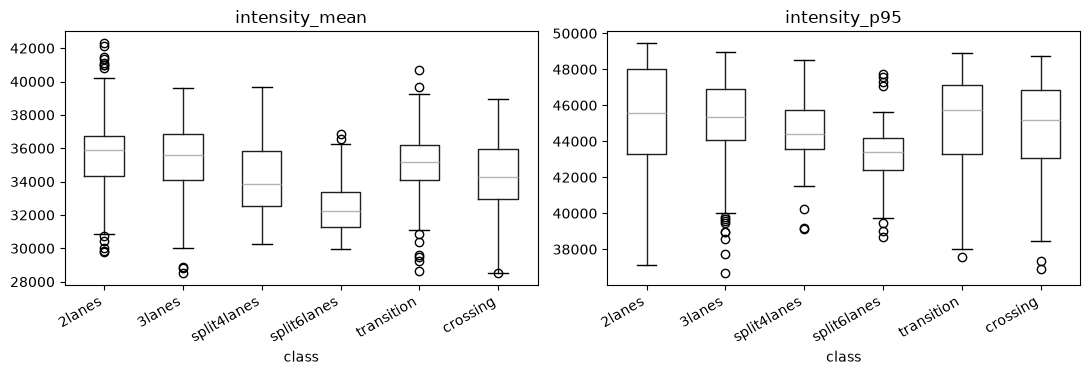

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.boxplot(column="intensity_mean", by="class", ax=axes[0], grid=False)
df.boxplot(column="intensity_p95", by="class", ax=axes[1], grid=False)
for ax, title in zip(axes, ["intensity_mean", "intensity_p95"]):
    ax.set_xticklabels(CLASSES, rotation=30, ha="right")
    ax.set_title(title)
plt.suptitle("")
plt.tight_layout()
plt.show()

## 5. Feature redundancy check

123 features from ~1140 training rows is generous for a Random Forest but can hurt an SVM,
so it's worth flagging obviously redundant pairs before M2 model training. We look at the
correlation matrix restricted to a handful of columns most likely to duplicate each other:
the four explicit geometric features, plus the mean/p50 pair for a few aggregate columns
(mean and median are often near-identical for roughly symmetric distributions).

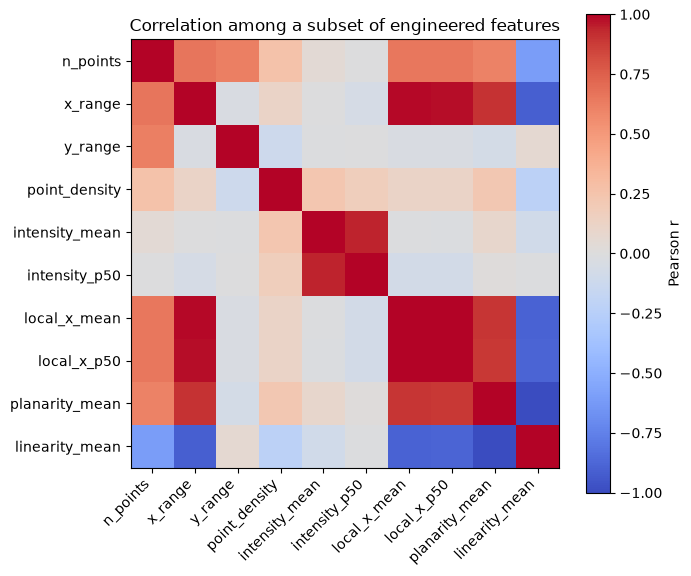

In [7]:
subset_cols = [
    "n_points", "x_range", "y_range", "point_density",
    "intensity_mean", "intensity_p50",
    "local_x_mean", "local_x_p50",
    "planarity_mean", "linearity_mean",
]
corr = df[subset_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(subset_cols))); ax.set_xticklabels(subset_cols, rotation=45, ha="right")
ax.set_yticks(range(len(subset_cols))); ax.set_yticklabels(subset_cols)
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Correlation among a subset of engineered features")
plt.tight_layout()
plt.show()

**Observation:** pairs with |r| > 0.9 in this subset:

- `x_range` / `local_x_mean`: r = 0.99
- `x_range` / `local_x_p50`: r = 0.98
- `x_range` / `planarity_mean`: r = 0.91
- `x_range` / `linearity_mean`: r = -0.91
- `intensity_mean` / `intensity_p50`: r = 0.94
- `local_x_mean` / `local_x_p50`: r = 1.00
- `planarity_mean` / `linearity_mean`: r = -1.00

`mean`/`p50` pairs correlating strongly is expected (median ≈ mean for roughly symmetric
columns) and not a bug — it just means we could drop one of each pair later without losing
much information, which matters more for a distance-based model like SVM than for Random
Forest (which is robust to redundant/correlated features by construction).

The `x_range` / `planarity_mean` / `linearity_mean` correlations are a more interesting find:
wider tiles tend to be flatter (higher planarity, lower linearity) on average. That makes
physical sense — a wide road surface is a large flat plane, while a narrow tile's points are
relatively more dominated by edge-like structures (curbs, markings) — but it also means
`x_range` is partly redundant with the geometry-descriptor stats, not just with its own
`local_x` mean/percentiles.

## 6. Next steps

The engineered features carry visible per-class signal without needing to look at the raw
points, so the plan from here (remaining M2 items in `ROADMAP.md`):

1. `src/baseline.py` — train Random Forest and SVM classifiers on `X_train`/`y_train`, using
   `build_feature_matrix(splits["val"])` for model selection (never `splits["test"]`).
2. A shared evaluation function (accuracy, precision/recall, IoU — weighted and per-class) so
   M3's CNN can be compared against this baseline on identical metrics.
3. Revisit the redundancy check above if SVM performance looks worse than Random Forest —
   dropping the correlated `p50` columns would be the first thing to try.